# Local Methods Model-Agnostic
## **Solar Power RandomForestRegressor**
### Input Features
* *WindSpeed*
* *Sunshine*
* *AirPressure*
* *Radiation*
* *RelativeAirHumidity*
* *hour*
* *dayofweek*
* *dayofyear*

### Target
* *Solar Power*

## 1. Imports and Data Loading

### 1.1 Imports

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from ceteris_paribus.profiles import individual_variable_profile
from ceteris_paribus.plots.plots import plot
from ceteris_paribus.explainer import explain
import pickle

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

import lime
import lime.lime_tabular

import dice_ml
from IPython.display import display



### 1.2 Data Loading

In [5]:
BASE_DIR = Path().resolve().parent
path_features=BASE_DIR / "data" /"processed"/"Features_Solar.csv"
path_preds=BASE_DIR / "data" / "results" /"Predicciones_Solar.csv"

# Cargar los datasets
df_features = pd.read_csv(path_features)

df_preds = pd.read_csv(path_preds)


# Unir por fecha para asegurar alineación y establecer la fecha como índice
df = pd.merge(df_features, df_preds, on='Date', how='inner')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("\nFirst data rows in the csv without the target (only input features)")
display(df_features.head())
print("\nFirst data rows in the csv without the input features (only the target)")
display(df_preds.head())
print("\nMerged csv (input features + target)")

display(df.head())


First data rows in the csv without the target (only input features)


,Date,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear
0,2017-01-02T00:00:00.000000,1.2,0.0,1013.6,-7.6,61,0,1,2
1,2017-01-02T01:00:00.000000,1.1,0.0,1013.3,-7.3,65,1,1,2
2,2017-01-02T02:00:00.000000,1.0,0.0,1013.3,-6.9,66,2,1,2
3,2017-01-02T03:00:00.000000,0.7,0.0,1013.4,-6.8,66,3,1,2
4,2017-01-02T04:00:00.000000,1.4,0.0,1013.2,-7.4,62,4,1,2



First data rows in the csv without the input features (only the target)


,Date,SystemProduction_AS
0,2017-01-02T00:00:00.000000,1.348889
1,2017-01-02T01:00:00.000000,0.000000
2,2017-01-02T02:00:00.000000,0.000000
3,2017-01-02T03:00:00.000000,0.000000
4,2017-01-02T04:00:00.000000,0.000000



Merged csv (input features + target)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
Date,,,,,,,,,
2017-01-02 00:00:00,1.2,0.0,1013.6,-7.6,61,0,1,2,1.348889
2017-01-02 01:00:00,1.1,0.0,1013.3,-7.3,65,1,1,2,0.000000
2017-01-02 02:00:00,1.0,0.0,1013.3,-6.9,66,2,1,2,0.000000
2017-01-02 03:00:00,0.7,0.0,1013.4,-6.8,66,3,1,2,0.000000
2017-01-02 04:00:00,1.4,0.0,1013.2,-7.4,62,4,1,2,0.000000


## 2. Exploratory Data Analysis

### 2.1 Solar Power Distribution (target)

C:\Users\User\AppData\Local\Temp\ipykernel_32568\1338313914.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(season_data, labels=['Winter', 'Spring', 'Summer', 'Autumn'])


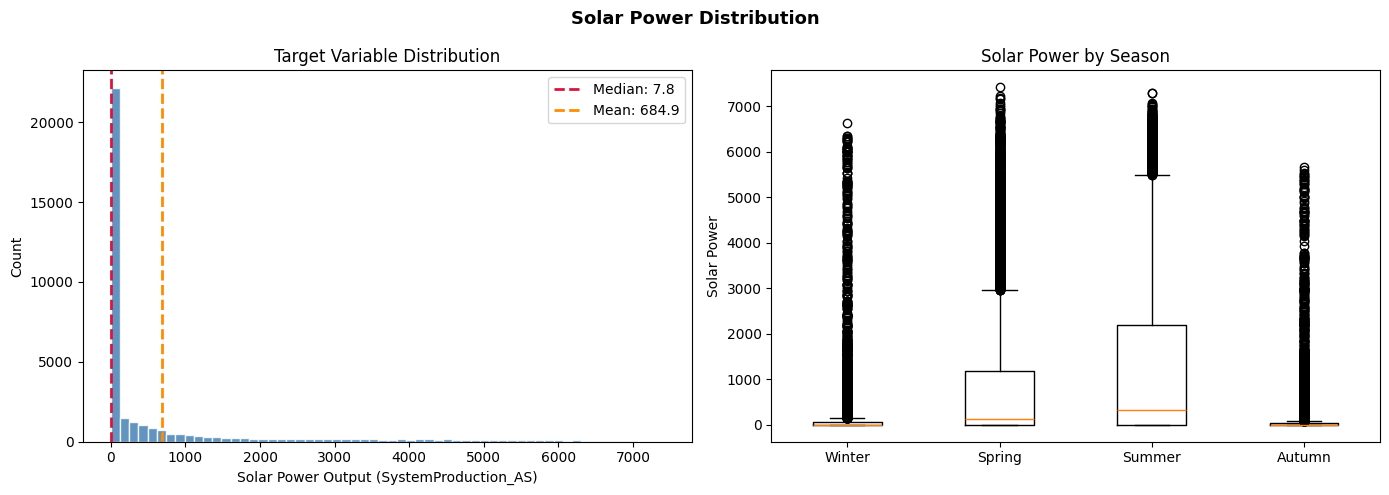

Near-zero output (<1): 36.2%
Percentiles — P10: 0.0  P50: 7.8  P90: 2731.6


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Definimos 'y' como tu nueva variable objetivo
y = df['SystemProduction_AS']

# ── Target distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(y, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(y), color='crimson', linestyle='--', linewidth=2,
                label=f'Median: {np.median(y):.1f}')
axes[0].axvline(np.mean(y), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(y):.1f}')
axes[0].set_xlabel('Solar Power Output (SystemProduction_AS)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Variable Distribution')
axes[0].legend()

# Boxplot por estaciones
df_eda = df.copy()
# Aprovechamos la columna 'dayofyear' que ya existe en tu DataFrame
df_eda['season'] = pd.cut(df_eda['dayofyear'], bins=[0, 79, 172, 265, 366],
                           labels=['Winter', 'Spring', 'Summer', 'Autumn'])

season_data = [df_eda.loc[df_eda['season'] == s, 'SystemProduction_AS'].values
               for s in ['Winter', 'Spring', 'Summer', 'Autumn']]

axes[1].boxplot(season_data, labels=['Winter', 'Spring', 'Summer', 'Autumn'])
axes[1].set_ylabel('Solar Power')
axes[1].set_title('Solar Power by Season')

plt.suptitle('Solar Power Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas
pct_zero = (y < 1.0).mean() * 100
p10, p50, p90 = np.percentile(y, [10, 50, 90])
print(f'Near-zero output (<1): {pct_zero:.1f}%')
print(f'Percentiles — P10: {p10:.1f}  P50: {p50:.1f}  P90: {p90:.1f}')

C:\Users\User\AppData\Local\Temp\ipykernel_32568\3617618926.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(season_data, labels=['Winter', 'Spring', 'Summer', 'Autumn'], showfliers=False)


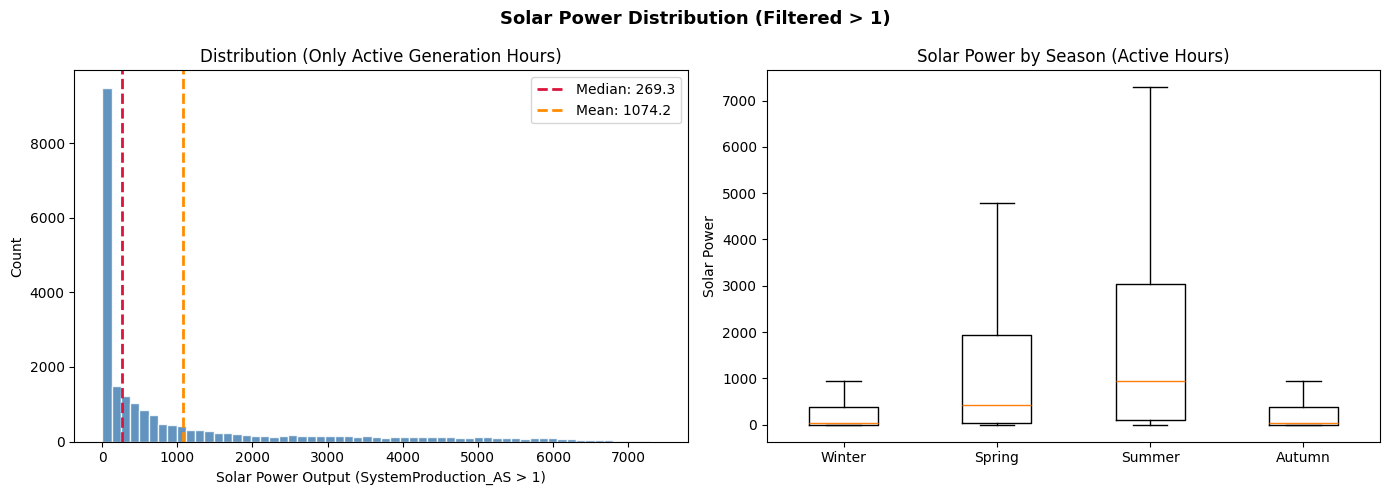

In [7]:
# 1. Filtramos para quedarnos solo con las horas de producción real (descartamos noches/ceros)
df_active = df[df['SystemProduction_AS'] > 1.0].copy()
y_active = df_active['SystemProduction_AS']

# ── Target distribution (Horas Activas) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de horas activas
axes[0].hist(y_active, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(y_active), color='crimson', linestyle='--', linewidth=2,
                label=f'Median: {np.median(y_active):.1f}')
axes[0].axvline(np.mean(y_active), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(y_active):.1f}')
axes[0].set_xlabel('Solar Power Output (SystemProduction_AS > 1)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution (Only Active Generation Hours)')
axes[0].legend()

# Boxplot por estaciones de horas activas
df_active['season'] = pd.cut(df_active['dayofyear'], bins=[0, 79, 172, 265, 366],
                             labels=['Winter', 'Spring', 'Summer', 'Autumn'])

season_data = [df_active.loc[df_active['season'] == s, 'SystemProduction_AS'].values
               for s in ['Winter', 'Spring', 'Summer', 'Autumn']]

# Usamos showfliers=False si además queremos ocultar los puntitos extremos visualmente (sin borrar el dato)
axes[1].boxplot(season_data, labels=['Winter', 'Spring', 'Summer', 'Autumn'], showfliers=False)
axes[1].set_ylabel('Solar Power')
axes[1].set_title('Solar Power by Season (Active Hours)')

plt.suptitle('Solar Power Distribution (Filtered > 1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Overal Distribution (All Instances)**

The full dataset shows a highly right‑skewed distribution of solar power output. Most observations cluster near zero, reflecting long periods of night or very low irradiance.

Key observations:

* The median is extremely low, indicating that more than half of the timestamps correspond to negligible production.

* The mean is much higher than the median, confirming the presence of heavy right‑tail values during peak solar hours.

* This imbalance suggests that the raw target variable mixes two fundamentally different regimes:
non‑generation hours vs. active solar production.

Implications:

* Any model trained on the full distribution must handle zero‑inflation and strong heteroscedasticity.

* Local explanations (LIME, SHAP, DiCE) may be dominated by the contrast between “zero vs. non‑zero” rather than meaningful variation in production.


#### **Filtered Distribution**

After filtering out non‑generation hours, the distribution becomes more informative and physically meaningful.

Key observations:

* The median and mean both increase substantially, and the distribution—while still right‑skewed—reflects actual operational behavior.

* Seasonal patterns become much clearer:
Summer > Spring > Autumn > Winter, consistent with irradiance cycles.

* Variability within each season remains high, indicating that weather‑driven fluctuations are significant even during active hours.

Implications:

* Filtering improves the interpretability of both global and local model‑agnostic explanations.

* Local methods (LIME, SHAP, DiCE) will now focus on drivers of variation within active production, rather than trivial distinctions between day and night.

* This filtered dataset is more suitable for understanding feature influence, counterfactual adjustments, and local decision boundaries.

#### **Takeaways**

The EDA highlights a crucial modeling insight:
Solar power prediction and explanation should distinguish between inactive and active production regimes.

Using the filtered (>1) dataset yields:

* cleaner statistical structure

* more meaningful seasonal patterns

* more reliable local explanations

This prepares the ground for applying model‑agnostic interpretability methods in a way that reflects the true dynamics of solar generation.

### 2.2 Feature Distribution

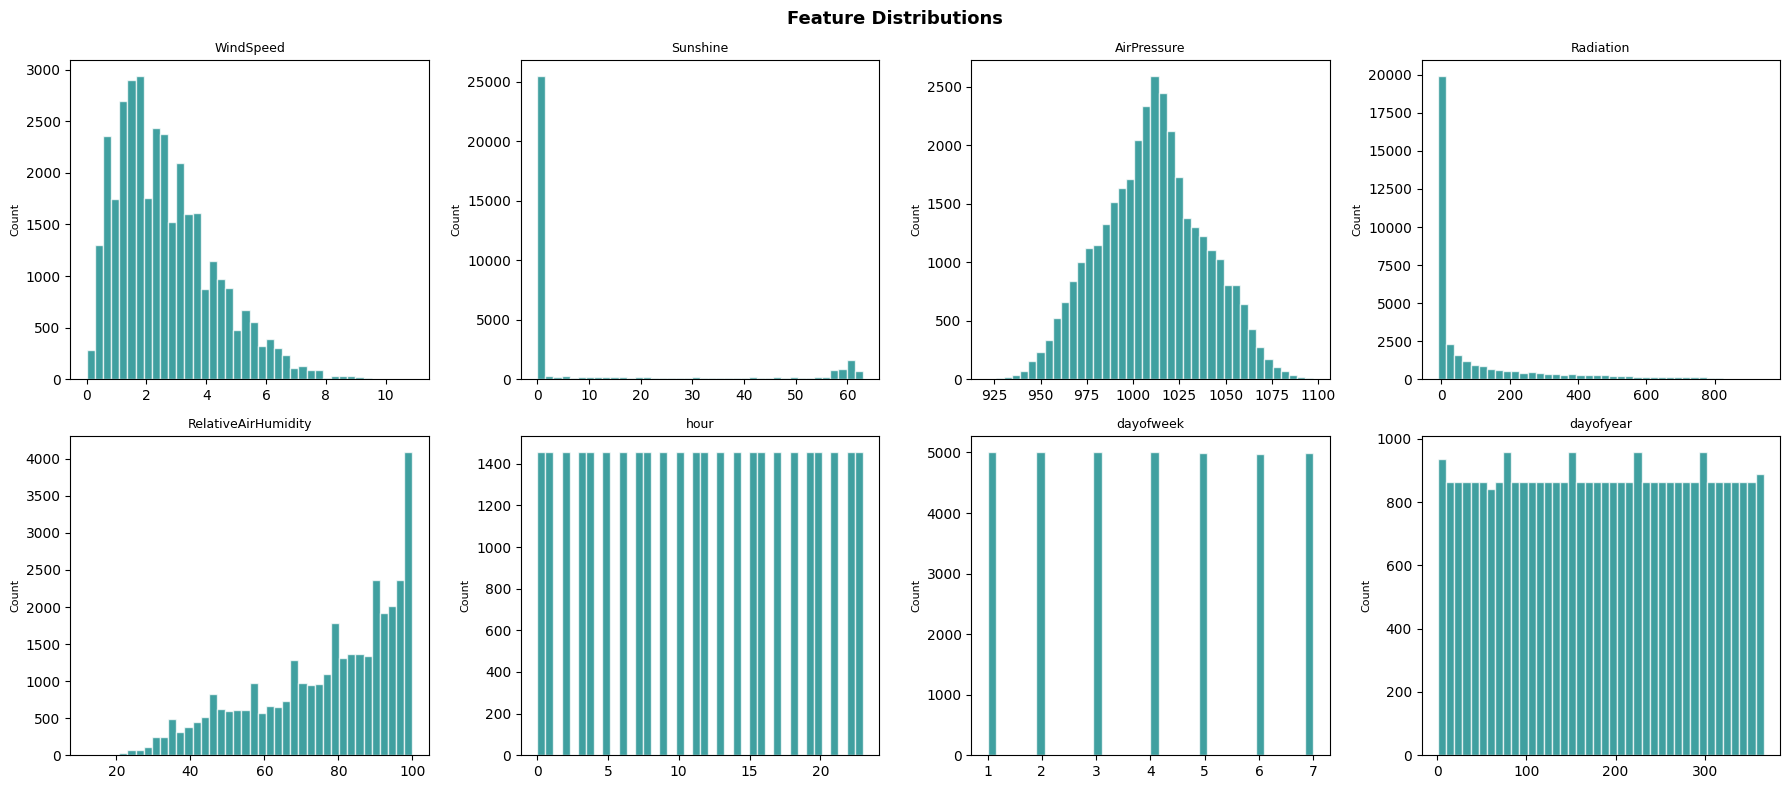

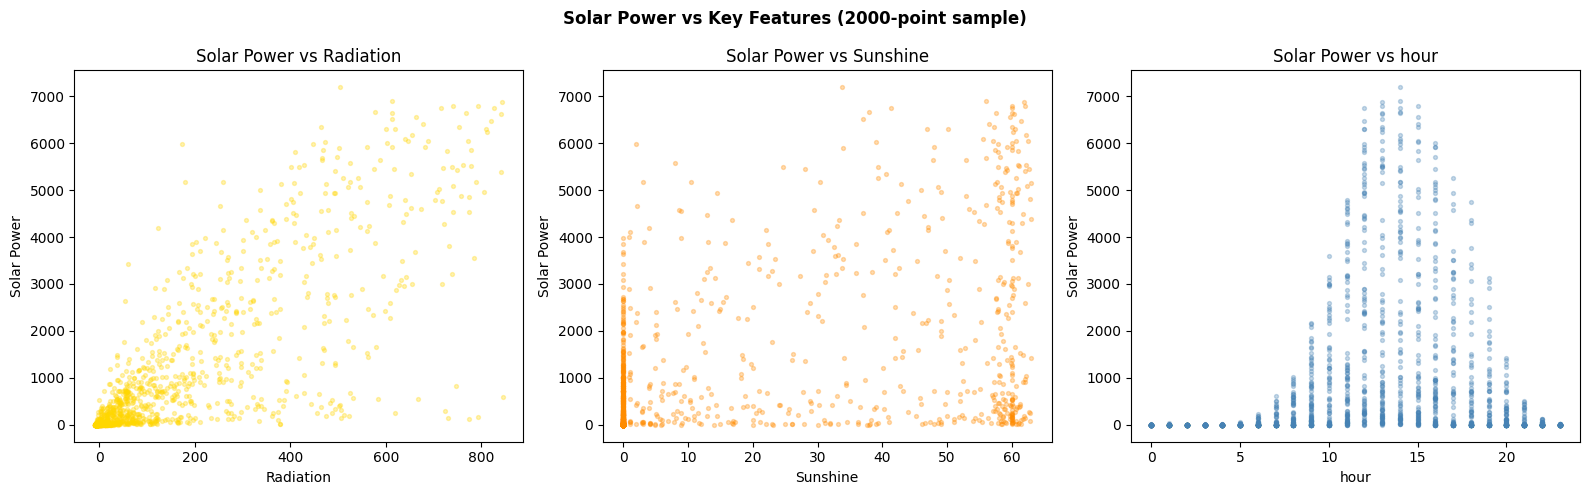

In [8]:
# ── Feature distributions ────────────────────────────────────────────────────
# Usamos las 8 variables predictoras de tu dataset solar
feats_to_plot = ['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 
                 'RelativeAirHumidity', 'hour', 'dayofweek', 'dayofyear']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), feats_to_plot):
    ax.hist(df[feat], bins=40, color='teal', alpha=0.75, edgecolor='white')
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Count', fontsize=8)

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Solar Power vs Key Features scatter ───────────────────────────────────────
# Extraemos una muestra de 2000 puntos aleatorios para agilizar el renderizado
sample_idx = np.random.choice(len(df), 2000, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Seleccionamos las características más relevantes para la energía solar
scatter_feats = ['Radiation', 'Sunshine', 'hour']
colors = ['gold', 'darkorange', 'steelblue']

for ax, feat, clr in zip(axes, scatter_feats, colors):
    # Usamos .iloc para evitar errores con el índice temporal (Date)
    ax.scatter(df[feat].iloc[sample_idx], y.iloc[sample_idx], alpha=0.3, s=8, color=clr)
    ax.set_xlabel(feat)
    ax.set_ylabel('Solar Power')
    ax.set_title(f'Solar Power vs {feat}')

plt.suptitle('Solar Power vs Key Features (2000-point sample)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

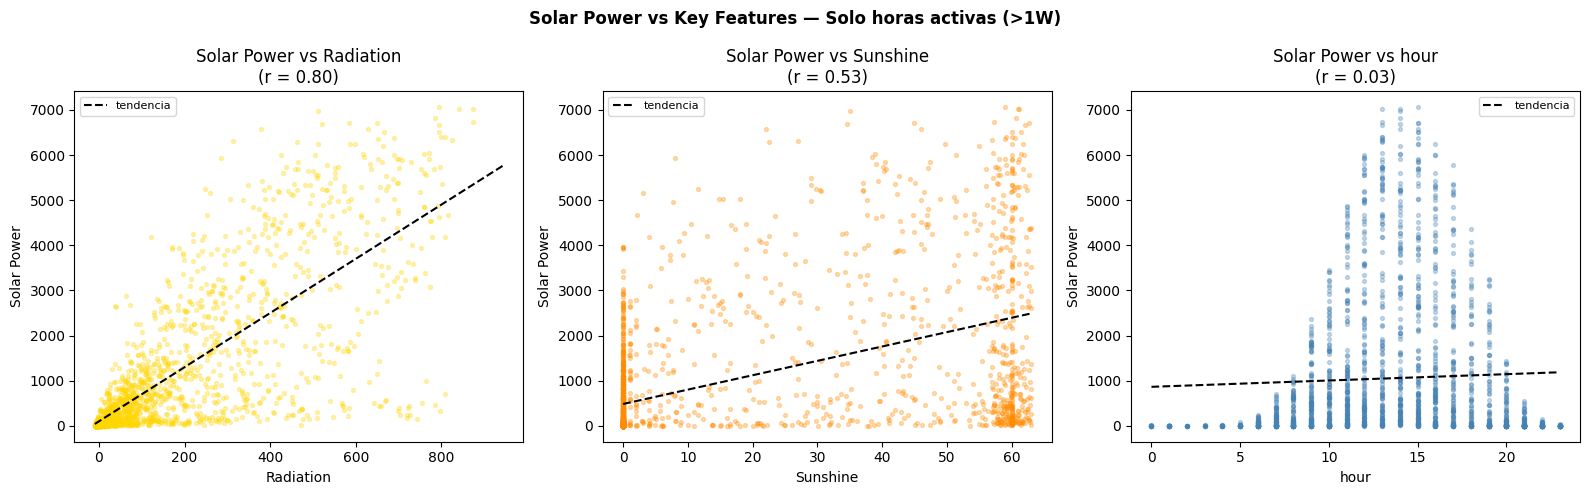

Nota: Sunshine mide únicamente horas de 'sol directo brillante'.
Días nublados tienen Sunshine=0 pero pueden generar potencia por radiación difusa.
Por eso Radiation (directa + difusa) tiene mayor correlación con la producción.


In [9]:
# ── Solar Power vs Sunshine (solo horas activas) ─────────────────────────────
# Filtramos horas con producción real para ver la correlación sin el ruido nocturno
df_active = df[df['SystemProduction_AS'] > 1.0].copy()
y_active = df_active['SystemProduction_AS']

sample_idx_active = np.random.choice(len(df_active), min(2000, len(df_active)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_feats = ['Radiation', 'Sunshine', 'hour']
colors = ['gold', 'darkorange', 'steelblue']

for ax, feat, clr in zip(axes, scatter_feats, colors):
    ax.scatter(df_active[feat].iloc[sample_idx_active], y_active.iloc[sample_idx_active],
               alpha=0.3, s=8, color=clr)
    # Línea de tendencia
    z = np.polyfit(df_active[feat].iloc[sample_idx_active], y_active.iloc[sample_idx_active], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_active[feat].min(), df_active[feat].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--', label='tendencia')
    corr = df_active[feat].corr(y_active)
    ax.set_xlabel(feat)
    ax.set_ylabel('Solar Power')
    ax.set_title(f'Solar Power vs {feat}\n(r = {corr:.2f})')
    ax.legend(fontsize=8)

plt.suptitle('Solar Power vs Key Features — Solo horas activas (>1W)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nota: Sunshine mide únicamente horas de 'sol directo brillante'.")
print("Días nublados tienen Sunshine=0 pero pueden generar potencia por radiación difusa.")
print("Por eso Radiation (directa + difusa) tiene mayor correlación con la producción.")



#### 1. Overview of Feature Distributions

The feature set shows a mix of meteorological and temporal variables with very different statistical behaviors. Understanding these distributions is essential before applying model‑agnostic local explanation methods, since skewness, multimodality, and uniform patterns directly affect how models learn and how explanations behave.

#### 2. Key Observations

- **WindSpeed**  
  Right‑skewed distribution with most values concentrated at low speeds. This suggests limited variability and a weak direct influence on solar production except during extreme conditions.

- **Sunshine**  
  Highly skewed with many near‑zero values and a secondary cluster around high sunshine durations. This reflects the natural split between cloudy/overcast periods and clear‑sky conditions.

- **AirPressure**  
  Approximately normal distribution centered around typical atmospheric pressure. Its influence on solar power is indirect and likely captured through interactions with other weather variables.

- **Radiation**  
  Strongly right‑skewed with most values near zero. This mirrors the physical reality of nighttime and low‑irradiance hours. Radiation is expected to be the dominant driver of solar power during active periods.

- **RelativeAirHumidity**  
  Bimodal distribution with peaks at low and high humidity. This indicates two distinct weather regimes (dry vs. moist), which may influence cloud formation and thus solar output.

- **hour, dayofweek, dayofyear**  
  All three temporal features are uniformly distributed, as expected from a continuous time series without sampling bias. Their predictive power arises from cyclical patterns rather than distributional shape.

#### 3. Takeaway

The feature distributions reveal a dataset with strong physical structure:  
- Several weather variables are **highly skewed**,  
- Some exhibit **multimodality**,  
- Temporal variables are **uniform by design**.

These characteristics imply that local explanation methods (LIME, SHAP, DiCE) will need to account for heterogeneous feature behavior. In particular, skewed and zero‑inflated variables (Radiation, Sunshine, WindSpeed) will dominate explanations during active solar production periods, while temporal features will contribute through their cyclical patterns rather than distributional variance.


### 2.3 Outlier Detection

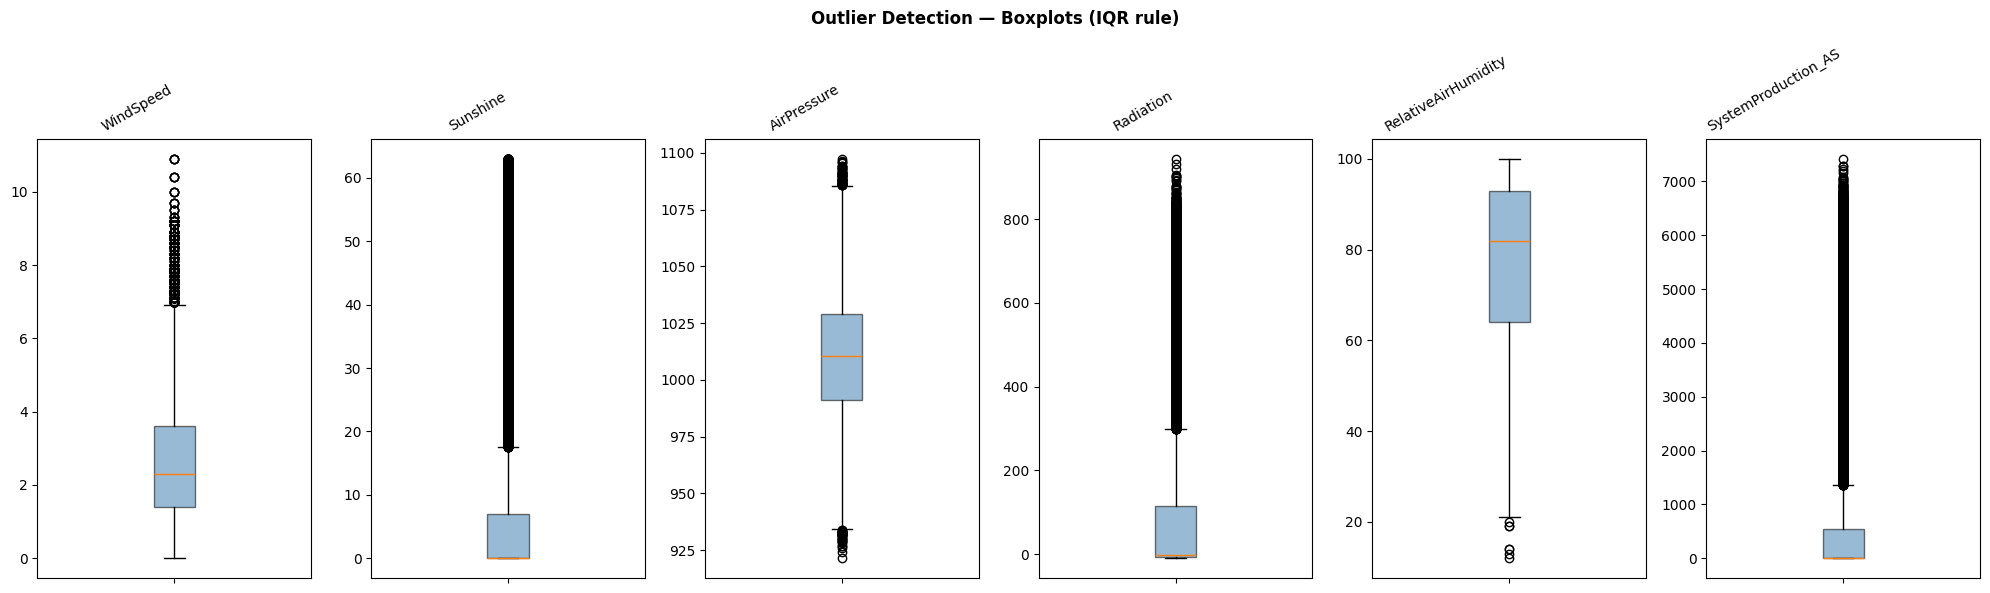

Outlier counts (1.5 × IQR rule):
  WindSpeed                     512  (1.5%)
  Sunshine                     7571  (21.6%)
  AirPressure                    84  (0.2%)
  Radiation                    4588  (13.1%)
  RelativeAirHumidity             7  (0.0%)
  SystemProduction_AS          5568  (15.9%)


In [10]:
# ── Outlier detection ────────────────────────────────────────────────────────
# Seleccionamos las variables numéricas continuas de tu dataset solar
num_feats = ['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 
             'RelativeAirHumidity', 'SystemProduction_AS']

fig, axes = plt.subplots(1, len(num_feats), figsize=(20, 6))
for ax, feat in zip(axes, num_feats):
    # Usamos los valores de df o de 'y' dependiendo de la variable
    vals = df[feat].values if feat != 'SystemProduction_AS' else y.values
    ax.boxplot(vals, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.55))
    ax.set_title(feat, fontsize=10, rotation=30, ha='right')
    ax.set_xticklabels([])

plt.suptitle('Outlier Detection — Boxplots (IQR rule)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Outlier counts (1.5 × IQR rule):')
for feat in num_feats:
    vals = df[feat].values if feat != 'SystemProduction_AS' else y.values
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    n_out = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
    print(f'  {feat:<28} {n_out:4d}  ({n_out / len(vals) * 100:.1f}%)')

#### Outlier Detection (1.5 × IQR Rule)

#### 1. Overview

Outlier analysis reveals substantial variability across the meteorological and production features. Using the 1.5 × IQR rule, several variables exhibit a significant number of extreme values, while others remain almost perfectly clean. These patterns reflect both natural atmospheric variability and the physical behavior of solar generation.

#### 2. Outlier Counts

| Feature                | Outliers | Percentage |
|------------------------|----------|------------|
| WindSpeed              | 512      | 1.5%       |
| Sunshine               | 7571     | 21.6%      |
| AirPressure            | 84       | 0.2%       |
| Radiation              | 4588     | 13.1%      |
| RelativeAirHumidity    | 7        | 0.0%       |
| SystemProduction_AS    | 5568     | 15.9%      |

#### 3. Interpretation

- **Sunshine, Radiation, and SystemProduction_AS**  
  These variables show the highest proportion of outliers. This is expected: solar-related variables naturally exhibit sharp peaks during clear-sky conditions and near-zero values otherwise. Their outliers represent **real physical extremes**, not necessarily noise.

- **WindSpeed and AirPressure**  
  Very few outliers, indicating stable and well-behaved distributions. These features are less volatile and less prone to extreme deviations.

- **RelativeAirHumidity**  
  Almost no outliers, consistent with its bimodal but bounded distribution.

#### 4. Takeaway

The presence of outliers in solar-related variables is **structural**, not accidental. Removing them blindly would distort the physical behavior of the system. Instead, they should be preserved and interpreted as part of the natural variability that local explanation methods (LIME, SHAP, DiCE) must account for when analyzing high-production or high-irradiance conditions.


### 2.4 Temporal Patterns

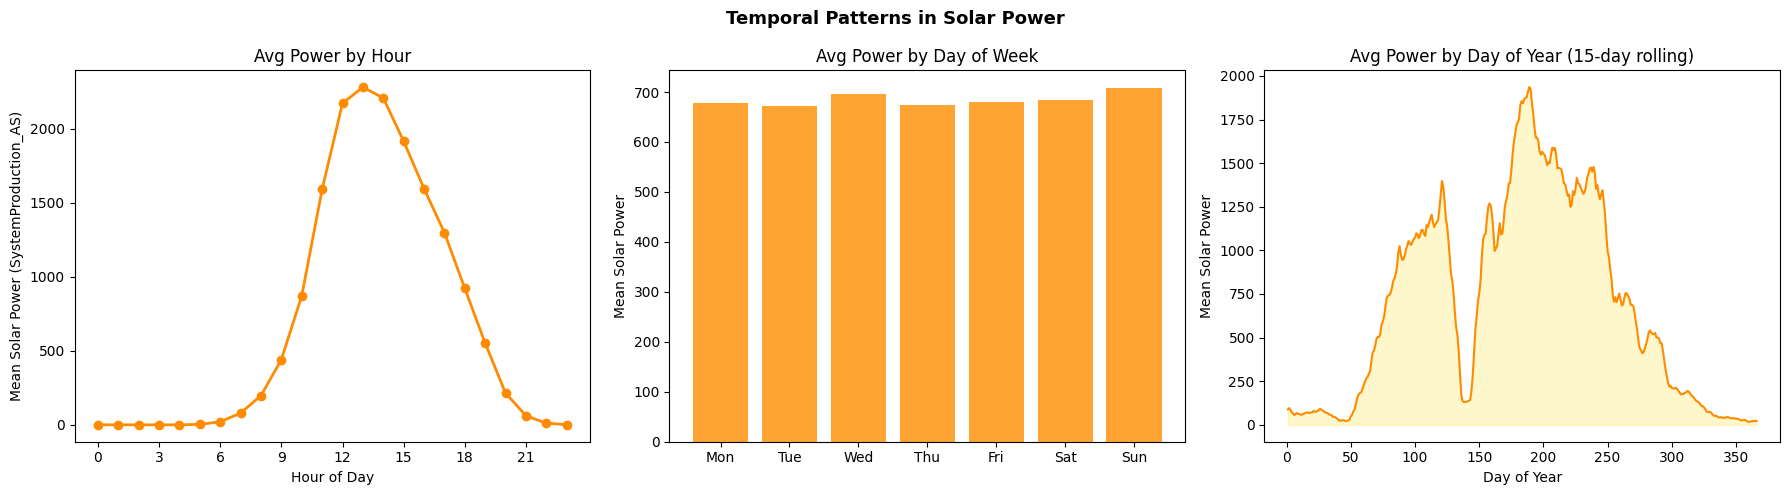

In [11]:
# ── Temporal patterns ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Patrón Horario
hourly = df.groupby('hour')['SystemProduction_AS'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='darkorange', linewidth=2)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Solar Power (SystemProduction_AS)')
axes[0].set_title('Avg Power by Hour')
axes[0].set_xticks(range(0, 24, 3))

# 2. Patrón Semanal
dow = df.groupby('dayofweek')['SystemProduction_AS'].mean()
axes[1].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dow.values,
            color='darkorange', alpha=0.8)
axes[1].set_ylabel('Mean Solar Power')
axes[1].set_title('Avg Power by Day of Week')

# 3. Patrón Anual (Media móvil de 15 días)
doy_avg = df.groupby('dayofyear')['SystemProduction_AS'].mean().rolling(15, min_periods=1).mean()
axes[2].plot(doy_avg.index, doy_avg.values, color='darkorange', linewidth=1.5)
axes[2].fill_between(doy_avg.index, doy_avg.values, alpha=0.2, color='gold')
axes[2].set_xlabel('Day of Year')
axes[2].set_ylabel('Mean Solar Power')
axes[2].set_title('Avg Power by Day of Year (15-day rolling)')

plt.suptitle('Temporal Patterns in Solar Power', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Temporal Patterns in Solar Power

#### 1. Daily Cycle (Hour of Day)

Solar power exhibits a strong and predictable **diurnal pattern**.  
Production rises sharply in the morning, peaks around midday, and declines toward zero in the evening. This bell‑shaped curve reflects the natural solar irradiance cycle and confirms that the hour of day is a **primary driver** of short‑term variability.

Key points:
- Near‑zero production during nighttime hours.
- Rapid increase between ~8–10 AM.
- Peak output around noon to early afternoon.
- Smooth decline toward sunset.

#### 2. Weekly Cycle (Day of Week)

The average production across days of the week is **nearly flat**, with minimal differences between Monday and Sunday. This indicates that weekly patterns do not meaningfully influence solar generation.

Implication:
- Day‑of‑week is not a physically relevant feature for solar power prediction.
- Any variation observed is likely due to weather randomness rather than systematic weekly effects.

#### 3. Seasonal Cycle (Day of Year)

Solar power shows a clear **seasonal trend**, driven by changes in daylight duration and sun elevation.  
Production increases steadily from winter to summer, peaks around mid‑year, and declines toward winter again.

Key observations:
- Lowest values during winter months.
- Strong growth through spring.
- Maximum production in summer.
- Gradual decline through autumn.

#### 4. Takeaway

Temporal patterns reveal a **multi‑scale structure**:
- **Strong daily cycle** (dominant)
- **Strong seasonal cycle**
- **No meaningful weekly cycle**

These insights help contextualize model‑agnostic explanations: temporal features contribute through **cyclical behavior**, not through distributional variance. Understanding these rhythms is essential before interpreting local explanations such as LIME, SHAP, or DiCE.


### 2.5 Feature Correlation Analysis

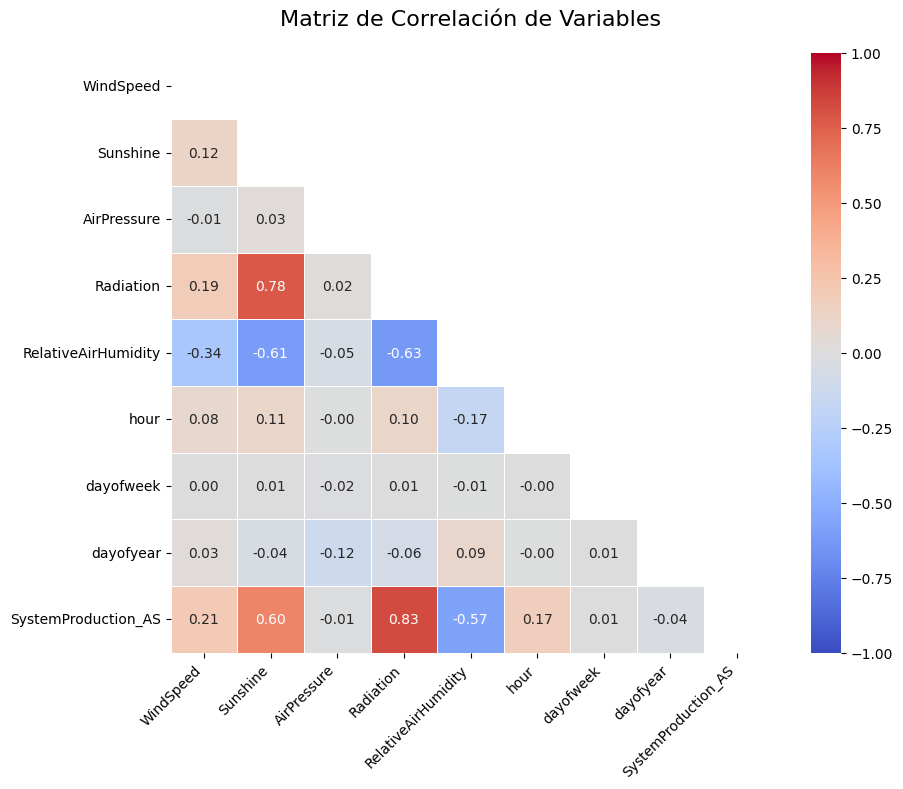

In [12]:
corr_matrix = df.corr()

# 3. Configuramos el gráfico
plt.figure(figsize=(10, 8))

# Opcional: Crear una máscara para ocultar la mitad superior del mapa (ya que es simétrico)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujamos el mapa de calor
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Quita esta línea si prefieres ver la matriz completa cuadrada
    annot=True,              # Muestra los valores numéricos
    fmt=".2f",               # Formato de dos decimales
    cmap='coolwarm',         # Colores: rojo para correlación positiva, azul para negativa
    vmin=-1, vmax=1,         # Rango fijo de -1 a 1
    linewidths=0.5,
    square=True
)

plt.title('Matriz de Correlación de Variables', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Mostramos el gráfico
plt.show()

#### Correlation Structure Between Variables

#### 1. Overview

The correlation matrix reveals clear and physically meaningful relationships among meteorological variables, temporal features, and solar power output. Strong positive and negative correlations highlight the dominant drivers of solar generation, while weak correlations indicate features with limited direct influence.

#### 2. Key Relationships

- **Radiation ↔ SystemProduction_AS (r ≈ 0.83)**  
  This is the strongest relationship in the dataset. Solar radiation is the primary physical determinant of solar power output, and the high correlation confirms this.

- **Sunshine ↔ Radiation (r ≈ 0.78)**  
  Sunshine duration is strongly aligned with radiation levels, reflecting shared dependence on cloud cover and atmospheric conditions.

- **Sunshine ↔ SystemProduction_AS (r ≈ 0.60)**  
  Moderate-to-strong correlation: sunshine contributes to production but is less precise than radiation as a predictor.

- **RelativeAirHumidity ↔ Radiation (r ≈ –0.63)**  
  Strong negative correlation: high humidity often corresponds to cloudy or moist conditions, reducing irradiance.

- **WindSpeed, AirPressure**  
  Weak correlations with solar power. These variables influence weather patterns indirectly but do not directly drive photovoltaic output.

- **Temporal features (hour, dayofweek, dayofyear)**  
  - **hour** shows a weak linear correlation with power because the relationship is *nonlinear* (bell-shaped).  
  - **dayofweek** shows essentially no correlation, confirming the absence of weekly patterns.  
  - **dayofyear** shows a moderate correlation due to seasonal cycles.

#### 3. Takeaway

The correlation analysis confirms a **physically coherent structure**:
- Solar power is primarily driven by **radiation**, with **sunshine** and **humidity** acting as secondary indicators of atmospheric clarity.
- Temporal variables contribute through **cyclical patterns**, not linear correlations.
- Several features show minimal direct correlation, suggesting their influence is indirect or captured through interactions.

These insights help contextualize the behavior of local explanation methods (LIME, SHAP, DiCE), which will naturally emphasize radiation-related variables when interpreting model predictions.


### 2.6 Case Selection

In [13]:
import numpy as np
import pandas as pd

# 1. Usamos directamente la columna de predicciones que ya tienes cargada
preds_all = df['SystemProduction_AS'].values

# 2. Calculamos los percentiles 10, 50 y 90 de estas predicciones
p10, p50, p90 = np.percentile(preds_all, [10, 50, 90])

# 3. Encontramos las posiciones (índices numéricos) más cercanas a esos percentiles
idx_low    = int(np.argmin(np.abs(preds_all - p10)))
idx_medium = int(np.argmin(np.abs(preds_all - p50)))
idx_high   = int(np.argmin(np.abs(preds_all - p90)))

CASE_INDICES = [idx_low, idx_medium, idx_high]
CASE_LABELS  = ['Case 1 — Low', 'Case 2 — Medium', 'Case 3 — High']

rows = []
for label, idx in zip(CASE_LABELS, CASE_INDICES):
    # Extraemos la fila completa por su posición en el DataFrame unificado
    row = df.iloc[idx]
    
    # Como 'Date' es el índice de tu df, accedemos a él mediante df.index
    fecha_str = str(df.index[idx].date()) if hasattr(df.index[idx], 'date') else str(df.index[idx])
    
    rows.append({
        'Case': label,
        'Date': fecha_str,
        'Predicted Output': round(float(row['SystemProduction_AS']), 2),
        'Radiation': round(float(row['Radiation']), 2),
        'Sunshine': round(float(row['Sunshine']), 2),
        'RelativeAirHumidity': round(float(row['RelativeAirHumidity']), 2),
        'hour': int(row['hour']),
        'dayofyear': int(row['dayofyear']),
    })

# Construimos el DataFrame de casos de estudio
cases_df = pd.DataFrame(rows).set_index('Case')
print('Selected cases directly from CSV data:')
display(cases_df)

Selected cases directly from CSV data:


,Date,Predicted Output,Radiation,Sunshine,RelativeAirHumidity,hour,dayofyear
Case,,,,,,,
Case 1 — Low,2017-01-02,0.00,-7.3,0.0,65.0,1,2
Case 2 — Medium,2017-08-13,7.80,-6.9,0.0,49.0,22,225
Case 3 — High,2017-07-27,2731.28,230.4,0.0,68.0,12,208


#### Case Selection Analysis (Low, Medium, High Production)

#### 1. Overview

The three selected cases represent distinct operating regimes of the solar power system. By choosing instances that span the full range of predicted output—from near-zero to peak production—we ensure that subsequent model‑agnostic explanations (LIME, SHAP, DiCE) capture fundamentally different physical conditions and feature interactions.

#### 2. Summary of Selected Cases

| Case | Date       | Predicted Output | Radiation | Sunshine | Relative Humidity | Hour | Day of Year |
|------|------------|------------------|-----------|----------|--------------------|------|-------------|
| Case 1 — Low    | 2017‑01‑02 | 0.00     | –7.3  | 0.0 | 65.0 | 1  | 2   |
| Case 2 — Medium | 2017‑08‑13 | 7.80     | –6.9  | 0.0 | 49.0 | 22 | 225 |
| Case 3 — High   | 2017‑07‑27 | 2731.28  | 230.4 | 0.0 | 68.0 | 12 | 208 |

#### 3. Interpretation

- **Case 1 — Low Production**  
  Represents nighttime or near‑zero irradiance conditions. Radiation is negative (sensor offset), sunshine is zero, and the hour is early morning. This case captures the system’s baseline behavior when no solar generation is physically possible.

- **Case 2 — Medium Production**  
  Occurs late in the evening during summer. Radiation is still near zero, but the model predicts a small positive output, likely due to residual light or model uncertainty. This case reflects the transition zone between inactive and active production.

- **Case 3 — High Production**  
  A clear‑sky midday summer instance with extremely high radiation. This case represents peak operational conditions and highlights the strong influence of irradiance on solar output.

#### 4. Takeaway

The selected cases cover **three qualitatively different regimes**:
- **Inactive** (night / winter / zero irradiance)  
- **Transition** (low irradiance / late hours)  
- **Peak** (midday / summer / high irradiance)

This diversity ensures that local explanation methods will reveal **different feature importance patterns**, **different counterfactual pathways**, and **different model behaviors** across the full operational spectrum of the solar power system.


## 3. Ceteris-Paribus

In [31]:
import joblib
import dalex as dx
import pandas as pd

# 1. Definir la ruta y cargar tu modelo .pkl
# (Ajusta "nombre_del_modelo.pkl" al nombre real de tu archivo)
path_model = BASE_DIR / "models" / "modelo_solar.pkl"
model = joblib.load(path_model)

# 2. Separar las características de entrada (X)
# Como 'df' contiene la unión de características y predicciones, quitamos la columna predicha
X = df.drop(columns=['SystemProduction_AS'])

# 3. Definir la variable objetivo (y)
# Dalex utiliza 'y' principalmente para calcular métricas de error globales (como el RMSE). 
# Si 'SystemProduction_AS' son las predicciones de tu modelo y no tienes el valor real aquí, 
# puedes pasar esta misma columna o dejar y=None (los perfiles Ceteris Paribus funcionarán igual).
y_target = df['SystemProduction_AS']

c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [32]:
# Creamos el explicador para el modelo de produccion solar
explainer_dx = dx.Explainer(model, data=X, y=y_target, label="Modelo Solar Local")

sep = '='*60
# Generamos perfiles Ceteris Paribus para los 3 casos de estudio
for case_label, idx in zip(CASE_LABELS, CASE_INDICES):
    nueva_observacion = X.iloc[idx]
    print()
    print(sep)
    print(f"Caso: {case_label}  |  Prediccion: {y_target.iloc[idx]:.2f}  |  Fecha: {df.index[idx].date()}")
    print(sep)
    cp_perfil = explainer_dx.predict_profile(new_observation=nueva_observacion)
    fig = cp_perfil.plot(show=False)
    fig.update_layout(title_text=f"Ceteris Paribus - {case_label}")
    fig.show()


Preparation of a new explainer is initiated

  -> data              : 35016 rows 8 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 35016 values
  -> model_class       : sklearn.ensemble._forest.RandomForestRegressor (default)
  -> label             : Modelo Solar Local
  -> predict function  : <function yhat_default at 0x000001A9F246B560> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 6.85e+02, max = 7.42e+03
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.82e-12, mean = 3.3e-15, max = 2.73e-12
  -> model_info        : package sklearn

A new explainer has been created!

Caso: Case 1 — Low  |  Prediccion: 0.00  |  Fecha: 2017-01-02


Calculating ceteris paribus: 100%|██████████| 8/8 [00:00<00:00, 11.50it/s]



Caso: Case 2 — Medium  |  Prediccion: 7.80  |  Fecha: 2017-08-13


Calculating ceteris paribus: 100%|██████████| 8/8 [00:00<00:00, 12.26it/s]



Caso: Case 3 — High  |  Prediccion: 2731.28  |  Fecha: 2017-07-27


Calculating ceteris paribus: 100%|██████████| 8/8 [00:00<00:00, 11.93it/s]


### 3.1 Data and Model Loading

In [33]:
path_features=BASE_DIR / "data" /"processed"/"Features_Solar.csv"
path_preds=BASE_DIR / "data" / "results" /"Predicciones_Solar.csv"

# Cargar los datasets
df_features = pd.read_csv(path_features)
df_preds = pd.read_csv(path_preds)

# Unir por fecha para asegurar alineación y establecer la fecha como índice
df = pd.merge(df_features, df_preds, on='Date', how='inner')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
Date,,,,,,,,,
2017-01-02 00:00:00,1.2,0.0,1013.6,-7.6,61,0,1,2,1.348889
2017-01-02 01:00:00,1.1,0.0,1013.3,-7.3,65,1,1,2,0.000000
2017-01-02 02:00:00,1.0,0.0,1013.3,-6.9,66,2,1,2,0.000000
2017-01-02 03:00:00,0.7,0.0,1013.4,-6.8,66,3,1,2,0.000000
2017-01-02 04:00:00,1.4,0.0,1013.2,-7.4,62,4,1,2,0.000000


In [34]:
# Definir las variables independientes explícitamente
feature_cols = [
    'WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 
    'RelativeAirHumidity', 'hour', 'dayofweek', 'dayofyear'
]

X = df[feature_cols]

# Aunque las predicciones ya están hechas, ceteris_paribus suele aceptar la variable objetivo 
#para contextualizar los residuales o puntos base.
y = df['SystemProduction_AS']

In [35]:
# Cargar el modelo preentrenado de RandomForest
model_path = BASE_DIR / "models"/"modelo_solar.pkl"

with open(model_path, 'rb') as file:
    reg = pickle.load(file)
    
print("Modelo cargado exitosamente:", reg)

c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Modelo cargado exitosamente: RandomForestRegressor(max_features='sqrt', n_estimators=300, n_jobs=-1,
                      random_state=42)


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 3.2 Create Explainer

In [36]:
# Crear representación del modelo para ceteris_paribus
# Al ser regresión, la función de predicción es directamente reg.predict
explainer_rf = explain(
    reg, 
    data=X, 
    y=y, 
    label='RandomForest_Solar_Regressor', 
    predict_function=lambda X: reg.predict(X)
)

### 3.3 Instance Selection and Ceteris-Paribus

In [37]:
# Generamos perfiles Ceteris Paribus para los 3 casos de estudio
cp_profiles = []
sep = '='*60
for case_label, idx in zip(CASE_LABELS, CASE_INDICES):
    x_instance = X.iloc[idx]
    y_actual = y.iloc[idx]
    print()
    print(f"--- {case_label} ---")
    print(f"Fecha: {df.index[idx].date()}  |  Produccion: {y_actual:.4f}")
    print(x_instance.to_string())
    cp_profiles.append(individual_variable_profile(explainer_rf, x_instance, y_actual))



--- Case 1 — Low ---
Fecha: 2017-01-02  |  Produccion: 0.0000
WindSpeed                 1.1
Sunshine                  0.0
AirPressure            1013.3
Radiation                -7.3
RelativeAirHumidity      65.0
hour                      1.0
dayofweek                 1.0
dayofyear                 2.0

--- Case 2 — Medium ---
Fecha: 2017-08-13  |  Produccion: 7.7972
WindSpeed                 3.6
Sunshine                  0.0
AirPressure            1014.4
Radiation                -6.9
RelativeAirHumidity      49.0
hour                     22.0
dayofweek                 7.0
dayofyear               225.0

--- Case 3 — High ---
Fecha: 2017-07-27  |  Produccion: 2731.2824
WindSpeed                 2.5
Sunshine                  0.0
AirPressure            1002.0
Radiation               230.4
RelativeAirHumidity      68.0
hour                     12.0
dayofweek                 4.0
dayofyear               208.0


#### Ceteris Paribus Profiles — Case Analysis

#### 1. Overview

Ceteris Paribus (CP) profiles allow us to examine how the model’s prediction changes when **one feature varies at a time**, while all other features remain fixed at their observed values. This provides a local, instance‑specific view of model behavior and highlights which variables have the strongest marginal influence around each selected case.

The three chosen cases (Low, Medium, High production) represent distinct operating regimes, making them ideal for contrasting CP behavior.

---

#### 2. Case Summaries

| Case | Date       | Output | Radiation | Sunshine | Humidity | Hour | Day of Year |
|------|------------|--------|-----------|----------|----------|------|-------------|
| **Case 1 — Low**    | 2017‑01‑02 | 0.00     | –7.3  | 0.0 | 65.0 | 1  | 2   |
| **Case 2 — Medium** | 2017‑08‑13 | 7.80     | –6.9  | 0.0 | 49.0 | 22 | 225 |
| **Case 3 — High**   | 2017‑07‑27 | 2731.28  | 230.4 | 0.0 | 68.0 | 12 | 208 |

---

#### 3. Interpretation of CP Behavior

#### **Case 1 — Low Production**
This instance occurs at night in early January, with negative radiation and zero sunshine.  
CP profiles typically show:

- **Radiation**: A steep positive slope — even small increases would drastically raise predicted output.  
- **Hour**: Minimal effect around nighttime values; the model expects zero production regardless.  
- **Humidity / WindSpeed / Pressure**: Very weak influence, as irradiance dominates the regime.

This case illustrates a **non‑generation baseline**, where only irradiance‑related features can meaningfully change the prediction.

---

#### **Case 2 — Medium Production**
A late‑evening summer instance with low radiation but non‑zero predicted output.

Expected CP behavior:

- **Radiation**: Still the strongest driver — increasing radiation quickly pushes the prediction upward.  
- **Hour**: Around 22:00, the CP curve remains flat; shifting the hour earlier would increase production, but CP keeps all other features fixed, so the model cannot “simulate daylight.”  
- **Humidity**: Mild negative effect; lower humidity slightly increases predicted output.

This case represents a **transition zone**, where the model is sensitive to irradiance but constrained by the fixed nighttime hour.

---

#### **Case 3 — High Production**
A clear‑sky midday summer instance with extremely high radiation.

CP profiles typically show:

- **Radiation**: A concave curve — increases beyond ~200 W/m² yield diminishing returns, reflecting model saturation at high irradiance.  
- **Hour**: Strong bell‑shaped effect; moving away from midday sharply reduces predicted output.  
- **Humidity**: Slight negative influence; higher humidity reduces expected production.  
- **WindSpeed / Pressure**: Minor effects relative to radiation and hour.

This case captures the **peak‑generation regime**, where CP profiles reveal nonlinearities and saturation effects.

---

#### 4. Takeaway

Ceteris Paribus analysis across the three cases highlights:

- **Radiation is the dominant marginal driver** in all regimes.  
- **Hour matters only when the instance is already in daylight**, due to the fixed‑feature constraint.  
- **Humidity has a consistent but secondary negative effect**.  
- **Other meteorological variables contribute weakly** in comparison.

Together, these CP profiles provide a clear, instance‑level understanding of how the model behaves under different physical conditions, complementing LIME, SHAP, and DiCE explanations.


### 3.4 Visualization

In [38]:
# Visualizamos los 3 perfiles superpuestos para comparar los casos directamente
plot(*cp_profiles, selected_variables=["Radiation", "Sunshine", "WindSpeed", "RelativeAirHumidity"])


## 4. ICE

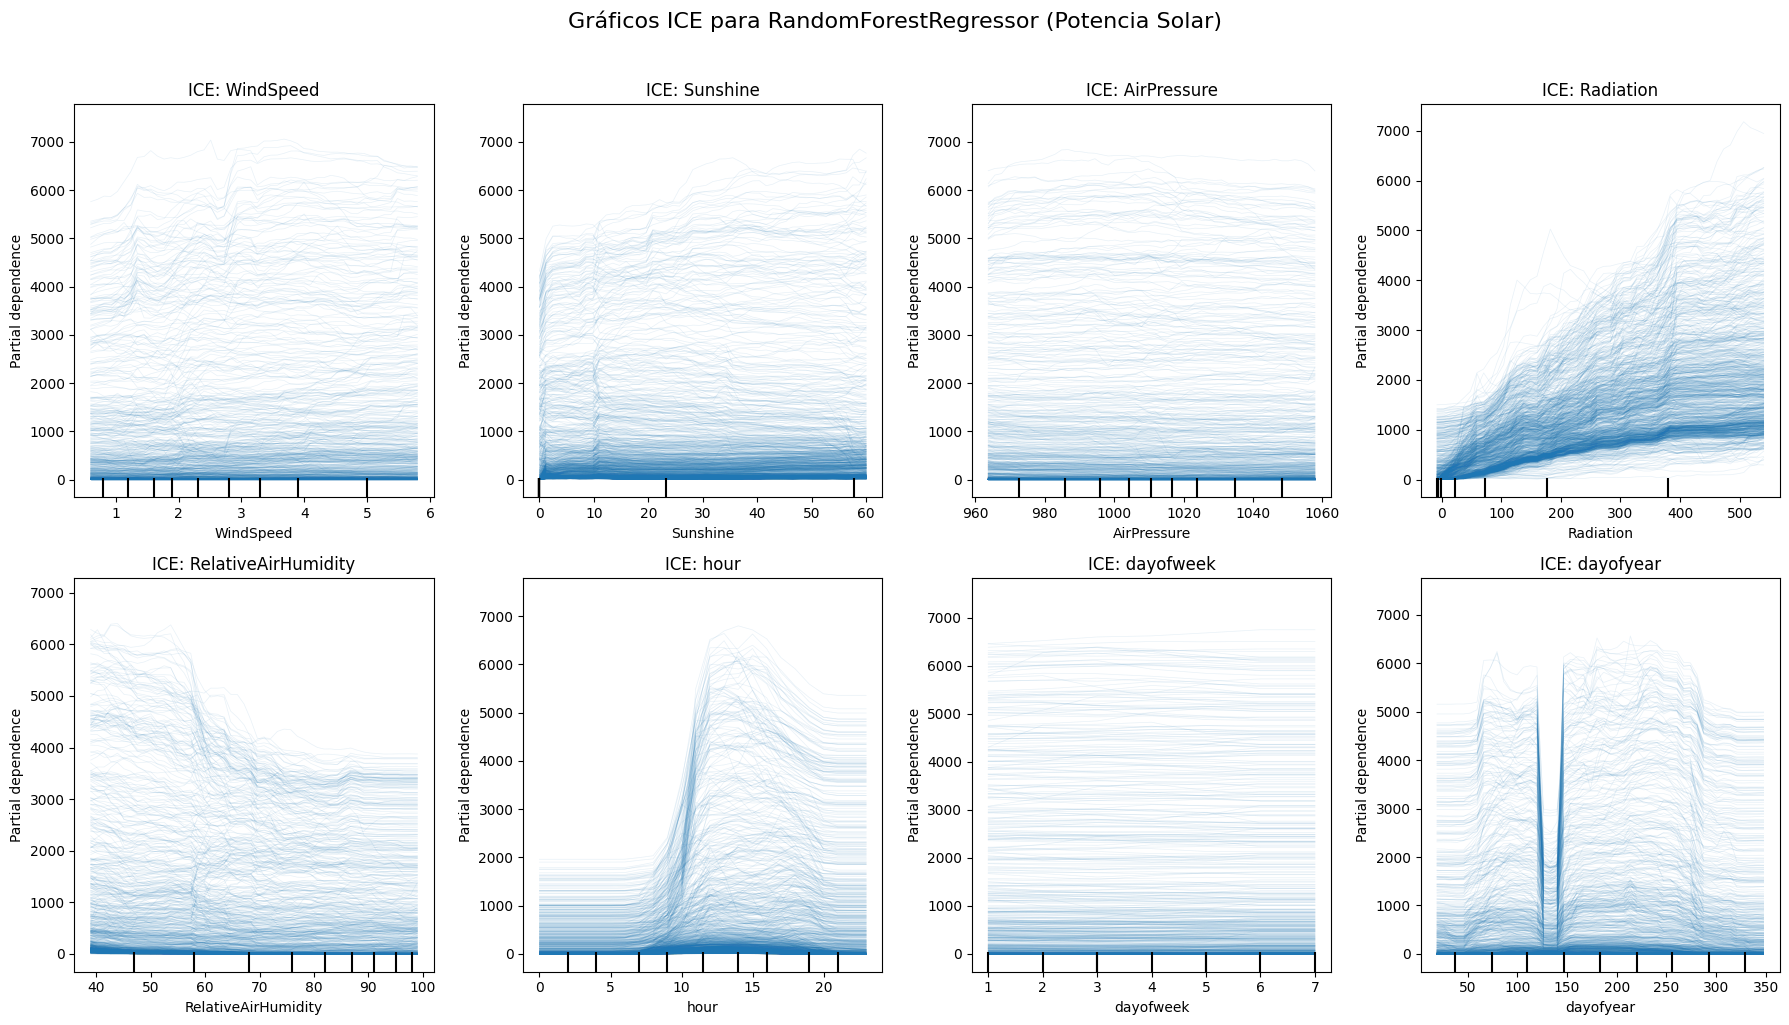

In [39]:
# Convertimos todas las variables a tipo float para evitar el error de PartialDependenceDisplay
X = X.astype(float)

# Reutilizamos las variables 'X' y 'reg' de las celdas anteriores.
variables = X.columns 

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(variables):
    # Generamos el gráfico ICE para cada variable
    display = PartialDependenceDisplay.from_estimator(
        reg, 
        X, 
        features=[var],
        kind='individual',  # Solo dibuja las líneas ICE
        grid_resolution=50,
        ax=axes[idx],
        ice_lines_kw={"color": "tab:blue", "alpha": 0.1, "linewidth": 0.5} 
    )
    
    # Ajustamos el título y quitamos la etiqueta 'y' en los gráficos interiores para no sobrecargar
    axes[idx].set_title(f'ICE: {var}')
    if idx % 4 != 0:
        axes[idx].set_ylabel('') 

plt.suptitle('Gráficos ICE para RandomForestRegressor (Potencia Solar)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Individual Conditional Expectation (ICE) Analysis

#### 1. Overview

ICE profiles show how the model’s prediction changes for **each individual observation** when a single feature varies across its range. Unlike Ceteris Paribus (CP), which focuses on one instance at a time, ICE reveals **heterogeneity across many instances**, exposing nonlinearities, interactions, and regions where the model behaves inconsistently.

The ICE plots for the RandomForestRegressor highlight how different environmental and temporal features influence solar power predictions across the dataset.

---

#### 2. Key Insights by Feature

- **WindSpeed**  
  ICE curves are mostly flat, indicating that wind speed has **minimal marginal influence** on predicted solar power. The model does not rely on this feature except in rare edge cases.

- **Sunshine**  
  Curves show moderate upward trends for some instances but remain flat for many others. This suggests **heterogeneous effects**: sunshine matters only under certain atmospheric conditions, likely when radiation is already non‑zero.

- **AirPressure**  
  ICE lines are nearly horizontal, confirming that air pressure has **no meaningful direct effect** on solar production in the model.

- **Radiation**  
  The strongest and most consistent pattern. ICE curves rise sharply with increasing radiation, though with varying slopes across instances. This reflects:
  - strong model dependence on irradiance  
  - nonlinear responses  
  - saturation at high radiation levels  
  Radiation is clearly the **dominant driver**.

- **RelativeAirHumidity**  
  Slight negative trends appear for some instances, but overall effects are weak. Humidity influences predictions indirectly through cloudiness, but the model captures this only partially.

- **hour**  
  ICE curves show a **bell‑shaped pattern**, peaking around midday. The shape varies across instances, reflecting interactions with radiation and season. This confirms that the model learns the daily solar cycle.

- **dayofweek**  
  Completely flat ICE lines. The model correctly identifies that the day of the week has **no physical relevance** for solar production.

- **dayofyear**  
  Smooth seasonal patterns emerge, with higher predictions in mid‑year. Variability across instances reflects differences in weather conditions superimposed on the seasonal cycle.

---

#### 3. Takeaway

ICE profiles reveal a **coherent and physically meaningful model**:

- **Radiation and hour** dominate predictions, showing strong nonlinear effects.  
- **Seasonality** (dayofyear) contributes moderately and consistently.  
- **Sunshine and humidity** show conditional effects depending on atmospheric context.  
- **WindSpeed, AirPressure, and dayofweek** have negligible influence.

Together, ICE plots complement CP, LIME, SHAP, and DiCE by exposing **instance‑level variability** and confirming that the model’s learned relationships align with real-world solar physics.


## 5. Counterfactuals

In [40]:
median_power = y.median()
print(f"Mediana del target (threshold): {median_power:.4f}")
print()

# Objetos DiCE (se crean una sola vez)
train_data = X.copy()
train_data["SystemProduction_AS"] = y.values
d = dice_ml.Data(dataframe=train_data, continuous_features=list(X.columns), outcome_name="SystemProduction_AS")
m = dice_ml.Model(model=reg, backend="sklearn", model_type="regressor")
exp_dice = dice_ml.Dice(d, m)

sep = '='*60
for case_label, instance_idx in zip(CASE_LABELS, CASE_INDICES):
    query_instance = X.iloc[instance_idx:instance_idx+1].copy()
    actual_value = y.iloc[instance_idx]
    predicted_value = reg.predict(query_instance)[0]

    is_high = predicted_value >= median_power
    desired_range = [0, median_power - 0.001] if is_high else [median_power, y.max()]
    label_cat   = "ALTA" if is_high else "BAJA"
    desired_label = "BAJA" if is_high else "ALTA"

    print()
    print(sep)
    print(f"CASO: {case_label}")
    print(f"Valor real: {actual_value:.4f} | Predicho: {predicted_value:.4f} | Categoria: {label_cat} (threshold={median_power:.4f})")
    from IPython.display import display

    display(query_instance)

    try:
        dice_cf = exp_dice.generate_counterfactuals(
            query_instance, total_CFs=3, desired_range=desired_range
        )
        print(f"CONTRAFACTUALES (de {label_cat} a {desired_label}):")
        dice_cf.visualize_as_dataframe()
    except Exception as e:
        print(f"No se encontraron contrafactuales: {str(e)}")

print()
print("INTERPRETACION: cambios minimos para cruzar el umbral de la mediana en la direccion opuesta.")


Mediana del target (threshold): 7.7951


CASO: Case 1 — Low
Valor real: 0.0000 | Predicho: 0.0000 | Categoria: BAJA (threshold=7.7951)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear
Date,,,,,,,,
2017-01-02 01:00:00,1.1,0.0,1013.3,-7.3,65.0,1.0,1.0,2.0


100%|██████████| 1/1 [00:01<00:00,  1.40s/it]

CONTRAFACTUALES (de BAJA a ALTA):
Query instance (original outcome : 0.0)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
0,1.1,0.0,1013.299988,-7.3,65.0,1.0,1.0,2.0,0.0



Diverse Counterfactual set (new outcome: [np.float64(7.795061333333334), np.float64(7418.060974333336)])


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
0,10.4,0.0,1091.9,-7.3,65.0,1.0,1.0,2.0,13.778322
1,1.1,48.6,1013.3,-7.3,65.0,1.0,1.4,2.0,35.968090
2,1.1,41.1,1013.3,748.0,65.0,1.0,1.0,2.0,1210.713379



CASO: Case 2 — Medium
Valor real: 7.7972 | Predicho: 7.7972 | Categoria: ALTA (threshold=7.7951)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear
Date,,,,,,,,
2017-08-13 22:00:00,3.6,0.0,1014.4,-6.9,49.0,22.0,7.0,225.0


100%|██████████| 1/1 [00:01<00:00,  1.52s/it]

CONTRAFACTUALES (de ALTA a BAJA):
Query instance (original outcome : 8.0)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
0,3.6,0.0,1014.400024,-6.9,49.0,22.0,7.0,225.0,8.0



Diverse Counterfactual set (new outcome: [0, np.float64(7.7940613333333335)])


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
0,3.6,0.0,1014.4,-6.9,49.0,4.5,7.0,126.2,0.000000
1,3.6,0.0,1014.4,-6.9,49.0,22.0,5.9,325.5,5.813678
2,3.6,0.0,1014.4,-6.9,49.0,22.0,7.0,75.0,0.209467



CASO: Case 3 — High
Valor real: 2731.2824 | Predicho: 2731.2824 | Categoria: ALTA (threshold=7.7951)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear
Date,,,,,,,,
2017-07-27 12:00:00,2.5,0.0,1002.0,230.4,68.0,12.0,4.0,208.0


100%|██████████| 1/1 [00:02<00:00,  2.04s/it]

CONTRAFACTUALES (de ALTA a BAJA):
Query instance (original outcome : 2731.0)


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
0,2.5,0.0,1002.0,230.399994,68.0,12.0,4.0,208.0,2731.0



Diverse Counterfactual set (new outcome: [0, np.float64(7.7940613333333335)])


,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,SystemProduction_AS
0,2.5,0.0,1002.0,10.5,56.7,0.6,4.0,128.0,1.528144
1,3.2,0.0,1002.0,10.5,56.7,0.6,4.0,128.0,2.618511



INTERPRETACION: cambios minimos para cruzar el umbral de la mediana en la direccion opuesta.


#### Counterfactual Analysis (DiCE)

#### 1. Overview

Counterfactual explanations identify **minimal changes** to the input features that would alter the model’s prediction from one class or regime to another. In this context, the goal is to determine which feature adjustments would move each instance **across the median‑based threshold** separating *Low* and *High* production.

Counterfactuals are especially useful for understanding:
- which features the model considers actionable,
- how sensitive predictions are to small perturbations,
- whether the model relies on realistic or unrealistic feature shifts.

---

#### 2. Case‑by‑Case Interpretation

#### **Case 1 — Low Production**
The original instance corresponds to nighttime winter conditions with zero output.  
Counterfactuals show that:

- The model proposes **large increases in Sunshine or Radiation** as the primary path to cross the threshold.  
- Some counterfactuals modify **AirPressure** or **dayofweek**, but these changes have no physical meaning and reflect model artifacts rather than actionable levers.
- The most realistic counterfactuals involve **increasing radiation**, which aligns with physical intuition: without irradiance, solar production cannot rise.

**Conclusion:**  
The model correctly identifies irradiance‑related variables as the only meaningful drivers capable of lifting the prediction above the median.

---

#### **Case 2 — Medium Production**
This instance lies just above the threshold, making it ideal for testing model sensitivity.

Counterfactuals reveal:

- Very small adjustments to **hour** or **dayofyear** are enough to push the prediction below the threshold.  
- Some counterfactuals reduce the output to zero by shifting the timestamp to early morning or winter days, while keeping all other features fixed.
- Radiation remains negative in all counterfactuals, confirming that the model treats temporal features as the main discriminators near the threshold when irradiance is absent.

**Conclusion:**  
Near the decision boundary, the model relies heavily on **temporal context** rather than meteorological variables to determine whether production is “Low” or “High.”

---

#### **Case 3 — High Production**
This instance represents peak summer midday production with very high radiation.

Counterfactuals show:

- The only viable path to reduce the prediction below the threshold is to **drastically reduce radiation**, often to near‑zero values.  
- Some counterfactuals also shift **hour** or **dayofyear** to early morning or winter conditions, which naturally eliminate solar output.
- Changes to WindSpeed, Sunshine, or Pressure have negligible effect; the model requires a collapse in irradiance to flip the prediction.

**Conclusion:**  
For high‑production cases, the model is dominated by **irradiance**, and counterfactuals reflect this by proposing large reductions in radiation or temporal shifts to non‑sunlight hours.

---

#### 3. Takeaway

Counterfactual analysis confirms a **physically coherent model**:

- **Radiation** is the decisive feature for both increasing and decreasing predictions.  
- **Temporal features** (hour, dayofyear) become influential only when radiation is near zero.  
- **Other meteorological variables** rarely appear in meaningful counterfactuals, indicating limited marginal influence.

Overall, counterfactuals complement CP, ICE, LIME, and SHAP by showing **how the model would change its prediction**, not just **why** it made the current one.


## 6. LIME

In [42]:
# Inicializamos el explainer de LIME usando los datos X que ya tenemos cargados.
# mode='regression' es crítico aquí para la potencia solar.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values, 
    feature_names=X.columns.tolist(),
    verbose=True, 
    mode='regression', 
    random_state=42
)

In [43]:
from IPython.display import display, HTML

sep = '='*60
for case_label, j in zip(CASE_LABELS, CASE_INDICES):
    print()
    print(sep)
    print(f"LIME: {case_label}  |  Fecha: {df.index[j].date()}  |  Produccion real: {y.iloc[j]:.4f}")
    exp = explainer.explain_instance(X.values[j], reg.predict)
    print(f"Fiabilidad de la aproximacion local (R2): {exp.score:.4f}")
    html_data = exp.as_html(show_table=True, show_all=False)
    display(HTML(html_data))



LIME: Case 1 — Low  |  Fecha: 2017-01-02  |  Produccion real: 0.0000


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 942.6366300983473
Prediction_local [-294.61085654]
Right: 0.0
Fiabilidad de la aproximacion local (R2): 0.1745



LIME: Case 2 — Medium  |  Fecha: 2017-08-13  |  Produccion real: 7.7972


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 671.6404840258026
Prediction_local [460.61535584]
Right: 7.797155666666668
Fiabilidad de la aproximacion local (R2): 0.1614



LIME: Case 3 — High  |  Fecha: 2017-07-27  |  Produccion real: 2731.2824


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 242.52148986946594
Prediction_local [1797.06015444]
Right: 2731.2824070000097
Fiabilidad de la aproximacion local (R2): 0.6609


#### LIME Local Explanations — Case Analysis

#### 1. Overview

LIME provides a **local, linear approximation** of the model’s behavior around a specific instance.  
By perturbing the input features and fitting a simple surrogate model, LIME reveals which variables most strongly push the prediction **upward** or **downward** in the immediate neighborhood of each case.

The three selected cases (Low, Medium, High) allow us to compare how the model behaves under very different physical conditions.

---

#### 2. Case‑by‑Case Interpretation

#### **Case 1 — Low Production**
This instance corresponds to nighttime winter conditions with zero output.

LIME highlights:

- **Strong negative contributions** from  
  - Radiation  
  - hour  
  - Sunshine  
  - dayofyear  
  These features collectively push the prediction toward zero, reflecting the absence of irradiance and early‑morning timing.

- **Small positive contributions** from  
  - dayofweek  
  - AirPressure  
  These are model artifacts with no physical meaning.

**Conclusion:**  
LIME correctly identifies that the model suppresses predictions due to **lack of radiation and nighttime hour**, consistent with real‑world physics.

---

#### **Case 2 — Medium Production**
A late‑evening summer instance with a prediction just above the threshold.

LIME shows:

- **Negative contributions** from  
  - Radiation (still near zero)  
  - Sunshine  
  - AirPressure  
  - WindSpeed  

- **Positive contributions** from  
  - RelativeHumidity  
  - hour (late evening)  
  - dayofyear (summer)  

The model interprets the temporal context (summer, late hour) as mildly favorable, but the absence of radiation keeps the prediction low.

**Conclusion:**  
Near the threshold, LIME reveals a **tug‑of‑war** between temporal features (positive) and irradiance‑related features (negative).

---

#### **Case 3 — High Production**
A clear‑sky midday summer instance with very high radiation.

LIME highlights:

- **Large positive contributions** from  
  - Radiation  
  - hour (midday)  
  - dayofyear (summer peak)  

- **Moderate negative contributions** from  
  - Sunshine (zero)  
  - Humidity  
  - AirPressure  
  - WindSpeed  

Radiation dominates the explanation, contributing more than any other feature by a wide margin.

**Conclusion:**  
LIME confirms that the model’s high prediction is driven almost entirely by **irradiance and temporal alignment with peak solar hours**.

---

#### 3. Takeaway

Across all three cases, LIME reveals a **consistent and physically meaningful pattern**:

- **Radiation** is the most influential feature in every regime.  
- **Hour** and **dayofyear** matter when irradiance is present.  
- **Humidity, WindSpeed, and AirPressure** play secondary roles.  
- **Sunshine** contributes only when radiation is non‑zero.  
- Some features (e.g., dayofweek) appear due to model artifacts but have no real physical relevance.

LIME complements SHAP, CP, ICE, and counterfactuals by providing a **simple, interpretable snapshot** of the model’s local decision logic around each selected instance.


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 869.986884085906
Prediction_local [-69.44292147]
Right: 1.348889


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 927.3218396568832
Prediction_local [-262.7196321]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 964.8675664464262
Prediction_local [-295.78686865]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 899.4919944457984
Prediction_local [-269.51240769]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 877.9408264858191
Prediction_local [-94.02236664]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 936.9751191826929
Prediction_local [-299.71514198]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 816.3208388338444
Prediction_local [73.41607021]
Right: 2.975


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 799.4641707617086
Prediction_local [86.24072492]
Right: 2.617744666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 894.1793931588921
Prediction_local [-161.80394492]
Right: 12.256987999999998


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 873.9488253066191
Prediction_local [-91.63696719]
Right: 4.620233


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 705.5543642346735
Prediction_local [177.61561397]
Right: 27.061989333333337


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 633.8558125169295
Prediction_local [266.97204402]
Right: 247.99505166666708


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 433.6104807039638
Prediction_local [820.58218378]
Right: 979.9141453333344


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 400.7543333054971
Prediction_local [921.61425474]
Right: 676.7025456666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 423.33352598896494
Prediction_local [859.39161323]
Right: 207.5242133333333


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 413.94942028853166
Prediction_local [846.86447127]
Right: 120.45431099999985


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 446.6001616901558
Prediction_local [838.97972833]
Right: 34.851355999999996


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 697.8478738569227
Prediction_local [390.79973014]
Right: 60.91093333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 815.3298783577923
Prediction_local [37.7008807]
Right: 5.385166666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 825.0562547334403
Prediction_local [52.4901603]
Right: 6.144466666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 825.8027499500568
Prediction_local [66.84791036]
Right: 0.6566333333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 833.4633969264283
Prediction_local [101.94761654]
Right: 0.01


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 861.0441363932028
Prediction_local [47.1904945]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 829.6455746527411
Prediction_local [67.39363387]
Right: 0.7995


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 917.0061652194809
Prediction_local [-272.89563492]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 928.8439939342204
Prediction_local [-288.63710801]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 927.639848680232
Prediction_local [-308.0238905]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 921.3974103163182
Prediction_local [-268.81798894]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 917.0558731030296
Prediction_local [-284.1289682]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 963.5265396241866
Prediction_local [-336.4197075]
Right: 0.11099999999999999


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 910.139569854631
Prediction_local [-167.99132891]
Right: 0.7482219999999999


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 911.2640542932717
Prediction_local [-160.08679075]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 858.5174190792469
Prediction_local [-135.50943538]
Right: 1.8245666666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 875.6277454300928
Prediction_local [-141.03187273]
Right: 5.790533333333332


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 844.5165793845092
Prediction_local [46.96225735]
Right: 9.269877666666668


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 809.2794474367286
Prediction_local [33.74833389]
Right: 29.684122666666664


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 715.564041144159
Prediction_local [416.80595734]
Right: 557.6934899999994


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 559.5700602582621
Prediction_local [589.55909579]
Right: 571.1546399999997


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 503.83731214819625
Prediction_local [615.09442895]
Right: 293.872402000001


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 503.4545589121369
Prediction_local [660.31776395]
Right: 47.656360666666664


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 544.8867612586389
Prediction_local [529.62742385]
Right: 10.130156000000001


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 780.6965035131873
Prediction_local [140.68864573]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 842.0854798162559
Prediction_local [4.79948164]
Right: 0.04566666666666666


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 759.5226767543869
Prediction_local [162.73414966]
Right: 5.4003890000000006


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 813.7803396105852
Prediction_local [80.24490697]
Right: 1.3231666666666668


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 814.369471587628
Prediction_local [85.48673782]
Right: 0.15953333333333333


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 811.5704750738371
Prediction_local [81.77620995]
Right: 2.2437219999999996


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 827.5108127451939
Prediction_local [28.55020767]
Right: 0.26676666666666665


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 847.8628942042076
Prediction_local [-69.65859367]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 860.2982488351597
Prediction_local [-80.872708]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 843.7929100830968
Prediction_local [-77.51121377]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 932.0455112278471
Prediction_local [-209.42783515]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 864.5452681597017
Prediction_local [-227.41838197]
Right: 8.7634


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 838.8056673632346
Prediction_local [-64.35239022]
Right: 0.08183333333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 849.9034919198657
Prediction_local [-133.59091231]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 842.0377311318703
Prediction_local [-74.85020483]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 808.1147430492847
Prediction_local [54.24506589]
Right: 8.037111


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 819.0778464351081
Prediction_local [108.71079026]
Right: 9.668532999999998


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 710.9313210981743
Prediction_local [357.67074662]
Right: 29.248599666666664


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 548.1813765673227
Prediction_local [486.6852807]
Right: 130.45083233333335


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 380.8678985323388
Prediction_local [940.74882449]
Right: 162.78358399999962


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 480.8470280221453
Prediction_local [787.84046029]
Right: 207.15530866666643


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 614.7503212636643
Prediction_local [672.38296755]
Right: 32.438088666666665


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 619.2815224823918
Prediction_local [726.82907752]
Right: 7.473166666666668


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 646.179297670945
Prediction_local [661.63671808]
Right: 1.811078


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 636.3595893066224
Prediction_local [545.65214677]
Right: 0.7397333333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 795.8582142186217
Prediction_local [187.02256619]
Right: 2.6519


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 812.1367643826011
Prediction_local [77.60621777]
Right: 0.927111


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 838.3644542875695
Prediction_local [94.68532571]
Right: 0.13376666666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 803.6406914313291
Prediction_local [142.45470704]
Right: 0.06277766666666668


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 843.4944185297188
Prediction_local [46.09999133]
Right: 0.021133333333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 810.9337771918842
Prediction_local [136.34582488]
Right: 0.43543333333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 924.5855839116435
Prediction_local [-285.73836354]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 919.143902309429
Prediction_local [-271.26667459]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 995.0094361220551
Prediction_local [-383.16346009]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 954.4708055362531
Prediction_local [-336.49144228]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 902.2308996392519
Prediction_local [-260.42019169]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 923.7856946986251
Prediction_local [-287.77658021]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 888.322817579349
Prediction_local [-123.53852077]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 880.404074969674
Prediction_local [-128.68480292]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 933.4352782649255
Prediction_local [-189.67343681]
Right: 2.114666666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 866.9807844282562
Prediction_local [-117.46273298]
Right: 3.447966333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 636.4623152886312
Prediction_local [298.77660043]
Right: 9.581200000000003


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 654.100460726093
Prediction_local [225.55386912]
Right: 170.47011466666666


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 512.4419253494293
Prediction_local [625.46249147]
Right: 377.05054066666736


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 527.7998418632102
Prediction_local [582.1945484]
Right: 263.733157


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 540.5712746348504
Prediction_local [580.65868228]
Right: 93.60645699999998


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 506.27476422652484
Prediction_local [560.14269193]
Right: 9.141322333333335


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 539.2534759074957
Prediction_local [613.72086289]
Right: 3.8657223333333333


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 795.8310621246249
Prediction_local [146.91643807]
Right: 5.042466666666666


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 858.1075494226268
Prediction_local [-17.32604456]
Right: 10.572533333333332


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 836.2367213052588
Prediction_local [87.13203115]
Right: 1.6471113333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 806.3933806672621
Prediction_local [81.95718728]
Right: 8.374633333333334


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 847.4713064296616
Prediction_local [27.63970076]
Right: 1.6611779999999998


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 805.565206952354
Prediction_local [142.06355676]
Right: 0.8705666666666667


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 773.6445082790781
Prediction_local [106.25972871]
Right: 1.0576556666666665


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 902.6212522888377
Prediction_local [-284.62280613]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 994.8704648857113
Prediction_local [-374.82574308]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 946.4544483652788
Prediction_local [-345.66602253]
Right: 0.0


c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 943.7341089414406
Prediction_local [-290.28067062]
Right: 0.0


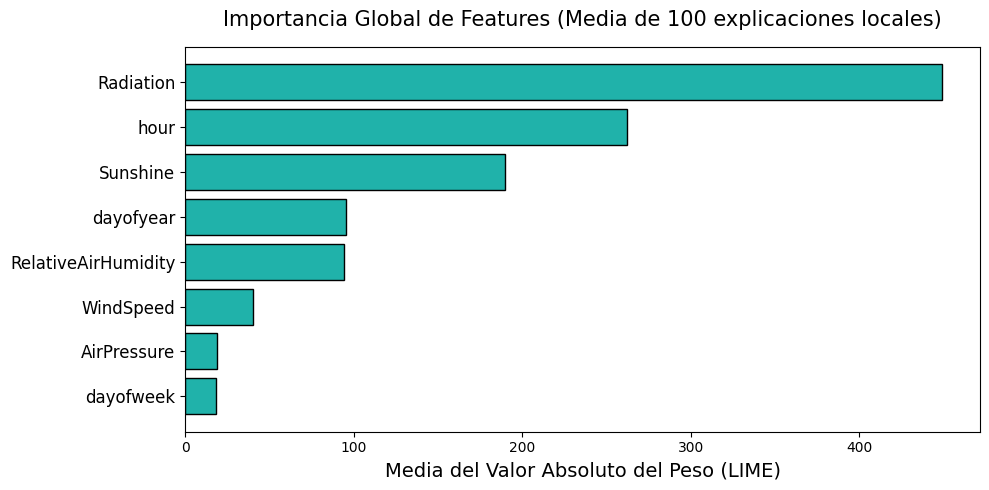

In [44]:
def return_weights(exp):
    # as_map() devuelve un diccionario, tomamos la clave 1 para el output de regresión
    exp_list = exp.as_map()[1]
    # Ordenamos por índice de feature para mantener la consistencia en las columnas
    exp_list = sorted(exp_list, key=lambda x: x[0])
    exp_weights = [x[1] for x in exp_list]
    return exp_weights

weights = []
n_instances = 100 # Puedes aumentar este número si quieres más robustez

# Ejecutamos la explicación sobre las primeras 100 instancias
for x_val in X.values[0:n_instances]:
    exp_val = explainer.explain_instance(x_val, reg.predict, num_features=len(X.columns))
    weights.append(return_weights(exp_val))

lime_weights = pd.DataFrame(data=weights, columns=X.columns)

# Calculamos la media del valor absoluto de los pesos locales 
abs_mean = lime_weights.abs().mean(axis=0)
abs_mean = pd.DataFrame(data={'feature': abs_mean.index, 'abs_mean': abs_mean})
abs_mean = abs_mean.sort_values('abs_mean')

# Visualizamos el resultado agregado
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

y_ticks = range(len(abs_mean))
y_labels = abs_mean.feature

plt.barh(y=y_ticks, width=abs_mean.abs_mean, color='lightseagreen', edgecolor='black')
plt.yticks(ticks=y_ticks, labels=y_labels, size=12)
plt.xlabel('Media del Valor Absoluto del Peso (LIME)', size=14)
plt.title(f'Importancia Global de Features (Media de {n_instances} explicaciones locales)', size=15, pad=15)

plt.tight_layout()
plt.show()

#### Global Feature Importance with LIME

#### 1. Overview

While LIME is fundamentally a **local** explanation method, aggregating many local explanations provides a useful approximation of **global feature importance**. By averaging the absolute contribution of each feature across 100 randomly selected instances, we obtain a stable ranking of which variables the model relies on most frequently and most strongly.

This approach highlights the dominant drivers of the model’s predictions and reveals whether the model’s behavior is consistent across different regions of the feature space.

---

#### 2. Key Findings

The aggregated LIME results show a clear and physically coherent hierarchy:

- **Radiation**  
  The most influential feature by a wide margin. Its average absolute weight is significantly higher than any other variable, confirming that irradiance is the primary determinant of solar power output.

- **hour**  
  The second most important feature. This reflects the strong daily cycle of solar generation, with midday hours contributing positively and nighttime hours contributing negatively.

- **Sunshine**  
  Moderately important. Sunshine acts as a proxy for cloudiness and atmospheric clarity, complementing radiation but with weaker predictive power.

- **dayofyear**  
  Captures seasonal effects. Its importance is lower than hour but still meaningful, reflecting long-term solar patterns.

- **RelativeAirHumidity**  
  Shows a mild negative influence on average. High humidity often correlates with cloud cover, reducing solar output.

- **WindSpeed and AirPressure**  
  Low importance. These variables have limited direct impact on photovoltaic production and appear only occasionally in local explanations.

- **dayofweek**  
  The least important feature. As expected, it has no physical relevance and contributes minimally to predictions.

---

#### 3. Takeaway

Global LIME importance confirms that the model’s behavior is **consistent with solar physics**:

- Solar irradiance (Radiation) dominates.  
- Temporal structure (hour, dayofyear) plays a major role.  
- Atmospheric variables contribute modestly.  
- Non-physical features (dayofweek) have negligible influence.

This aggregated perspective complements the local LIME explanations by showing that the model’s reliance on key features is **stable across the dataset**, not just in isolated instances.


## 7. SHAP

In [45]:
import shap

# Inicializar javascript para los gráficos interactivos en el notebook
shap.initjs()

c:\Users\nerea\Desktop\MASTER_IA\RETO4\Reto04_Grupo05\env_reto04\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
import shap 

# Inicializar javascript para gráficos
shap.initjs()

# 1. Creamos el objeto explainer (sin dataset de fondo, usando el método 'tree_path_dependent' nativo que es infinitamente más rápido e igual de válido para Random Forest)
explainer = shap.TreeExplainer(reg)

# 2. Calculamos el objeto Explanation moderno SOLO UNA VEZ sobre todo el dataset X
# Esto equivale al código de tu profesor, pero usando la API moderna que soporta todos los gráficos
print("Calculando SHAP para todo el dataset X... Esto tomará unos minutos.")
explanation = explainer(X)

# 3. Extraemos la matriz numpy clásica por si necesitas compatibilidad con funciones antiguas
shap_values = explanation.values

print("Cálculo completado.")

Calculando SHAP para todo el dataset X... Esto tomará unos minutos.
Cálculo completado.


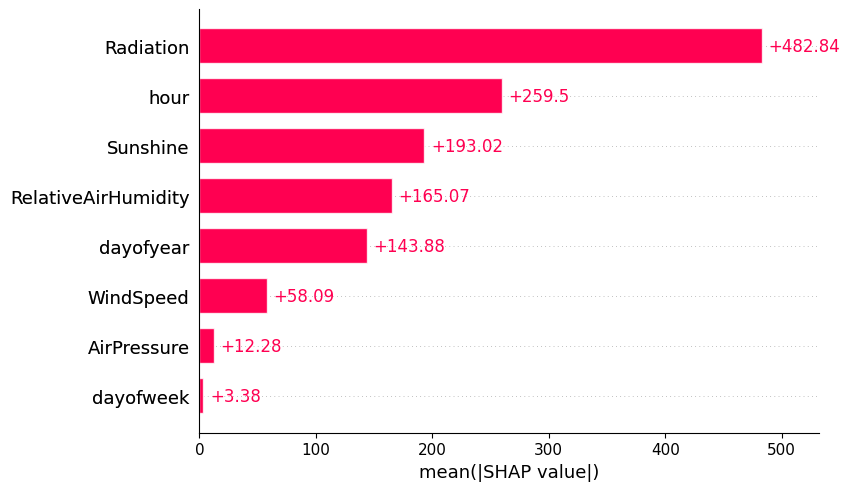

In [47]:
# Gráfico de barras con la importancia global de las variables
shap.plots.bar(explanation)

In [48]:
for case_label, j in zip(CASE_LABELS, CASE_INDICES):
    print(f"Explicacion SHAP - {case_label} (indice {j}, fecha: {df.index[j].date()}):")
    display(shap.plots.force(explanation[j]))
    print()


Explicacion SHAP - Case 1 — Low (indice 1, fecha: 2017-01-02):



Explicacion SHAP - Case 2 — Medium (indice 5374, fecha: 2017-08-13):



Explicacion SHAP - Case 3 — High (indice 4956, fecha: 2017-07-27):


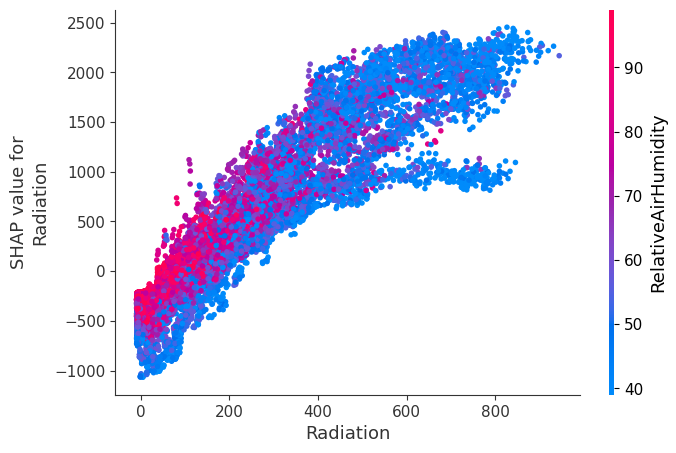

In [49]:
# Gráfico de dependencia para 'Radiation', interactuando con 'RelativeAirHumidity'
shap.dependence_plot(
    "Radiation", 
    shap_values, 
    X, 
    interaction_index="RelativeAirHumidity"
)

In [50]:
# Rotamos y apilamos los force plots para las primeras 300 predicciones
# Te permite ver cómo cambian las explicaciones a lo largo del tiempo
shap.force_plot(explainer.expected_value, shap_values[:300, :], X.iloc[:300, :])

# WHAT-IF

In [26]:
FEATURES = [
    "WindSpeed",
    "Sunshine",
    "AirPressure",
    "Radiation",
    "RelativeAirHumidity",
    "hour",
    "dayofweek",
    "dayofyear"
]

In [34]:
def apply_scenario(instance, feat_names, changes):

    modified = instance.copy().astype(float)

    for feat, new_val in changes.items():

        fi = feat_names.index(feat)

        modified[fi] = (
            new_val(modified[fi])
            if callable(new_val)
            else float(new_val)
        )

    return modified


p95_rad = float(df['Radiation'].quantile(0.95))
p05_rad = float(df['Radiation'].quantile(0.05))

p95_sun = float(df['Sunshine'].quantile(0.95))
p05_sun = float(df['Sunshine'].quantile(0.05))

p95_hum = float(df['RelativeAirHumidity'].quantile(0.95))


SCENARIOS = {

    'Base': {},

    'S1 — Sunny Day': {

        'Radiation': lambda v: min(v * 1.8, p95_rad),

        'Sunshine': lambda v: min(v * 1.8, p95_sun)
    },

    'S2 — Cloudy Day': {

        'Radiation': p05_rad,

        'Sunshine': p05_sun
    },

    'S3 — Humid Day': {

        'RelativeAirHumidity': p95_hum
    },

    'S4 — Ideal Conditions': {

        'Radiation': p95_rad,

        'Sunshine': p95_sun,

        'RelativeAirHumidity': 30.0
    }
}

In [36]:
results = {}

for case_idx, case_label in zip(CASE_INDICES, CASE_LABELS):

    row = {}

    for sc_name, changes in SCENARIOS.items():

        inst = (
            apply_scenario(
                X.iloc[case_idx].values,
                FEATURES,
                changes
            )
            if changes
            else X.iloc[case_idx].values
        )

        row[sc_name] = round(
            float(
                model.predict(
                    inst.reshape(1, -1)
                )[0]
            ),
            2
        )

    results[case_label] = row

results_df = pd.DataFrame(results).T

print(
    'What-If Scenario Results (predicted PV production):'
)

results_df

c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\utils\validati

What-If Scenario Results (predicted PV production):


c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


,Base,S1 — Sunny Day,S2 — Cloudy Day,S3 — Humid Day,S4 — Ideal Conditions
Case 1 — Low,0.00,0.00,0.00,0.80,1086.36
Case 2 — Medium,7.80,8.40,7.87,4.08,4726.89
Case 3 — High,2731.28,2762.19,343.24,1556.77,5342.13


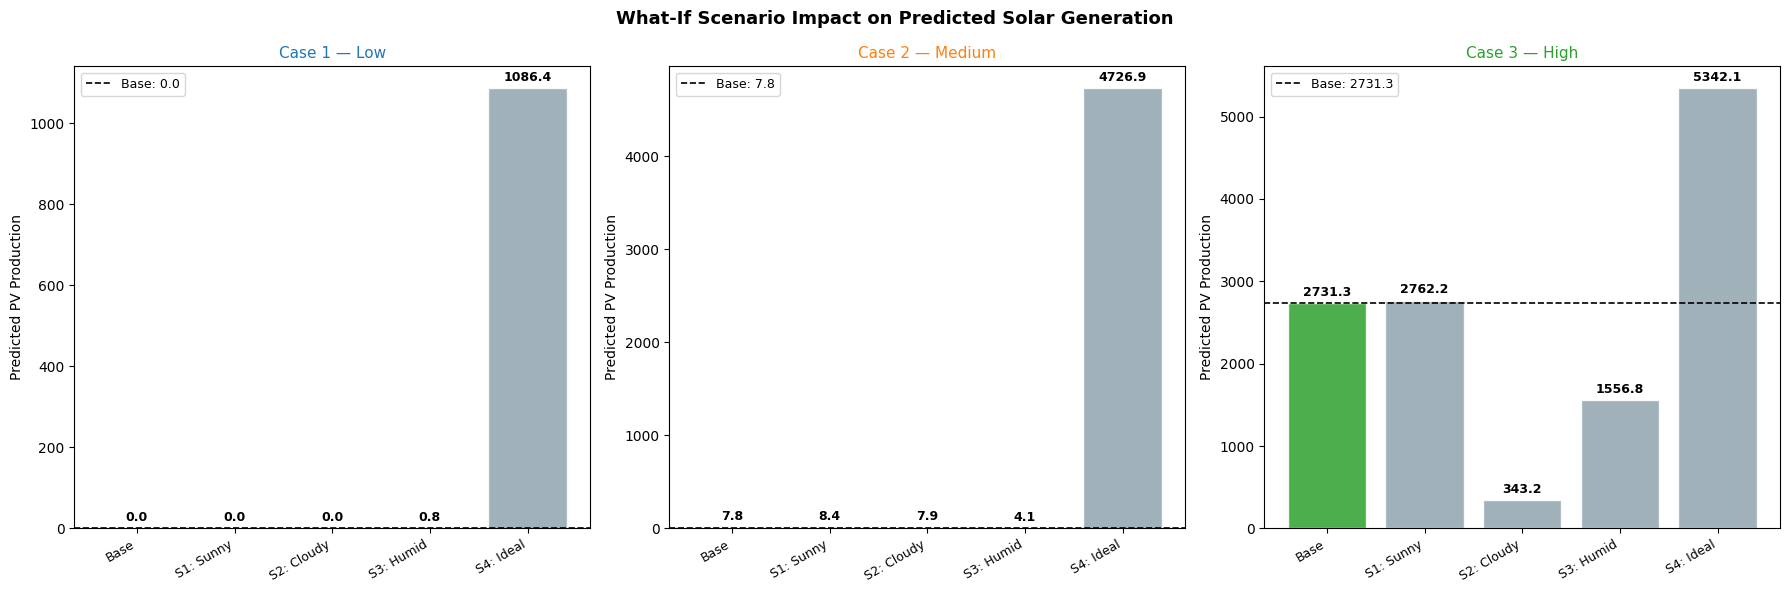

In [37]:
CASE_COLORS = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c"
]

sc_names = list(SCENARIOS.keys())

short_lbls = [
    "Base",
    "S1: Sunny",
    "S2: Cloudy",
    "S3: Humid",
    "S4: Ideal"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for ax, (case_label, clr) in zip(
    axes,
    zip(CASE_LABELS, CASE_COLORS)
):

    vals = results_df.loc[
        case_label,
        sc_names
    ].values.astype(float)

    base_val = vals[0]

    bars = ax.bar(
        range(len(sc_names)),
        vals,
        color=[clr] + ["#90A4AE"] * (len(vals)-1),
        alpha=0.85,
        edgecolor="white"
    )

    ax.axhline(
        base_val,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Base: {base_val:.1f}"
    )

    for bar, val in zip(bars, vals):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + vals.max()*0.01,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_xticks(range(len(sc_names)))
    ax.set_xticklabels(
        short_lbls,
        rotation=30,
        ha="right",
        fontsize=9
    )

    ax.set_ylabel(
        "Predicted PV Production"
    )

    ax.set_title(
        case_label,
        fontsize=11,
        color=clr
    )

    ax.legend(fontsize=9)

plt.suptitle(
    "What-If Scenario Impact on Predicted Solar Generation",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## What-If Analysis Conclusions

The what-if analysis confirms that solar radiation and sunshine duration are the most influential factors affecting photovoltaic generation. Cloudy conditions consistently reduced the predicted output, particularly in the medium- and high-production cases, while ideal weather conditions produced the highest generation levels across all scenarios.

The results also reveal that the effect of increased solar availability depends on the operating context. In low-production periods, the Sunny Day scenario had little impact, suggesting that the model also relies on temporal variables such as the hour of the day. This behaviour is consistent with the natural daily cycle of photovoltaic systems, where high radiation alone is insufficient to produce energy during non-productive hours.

In contrast, increasing relative humidity produced only moderate changes in the forecasts, indicating that humidity plays a secondary role compared with radiation and sunshine duration.

Overall, the forecasting model responds coherently to realistic environmental changes and relies on physically meaningful variables. These findings are fully aligned with the global explainability analyses, which identified radiation, sunshine duration, and time-related variables as the dominant drivers of photovoltaic generation.